<a href="https://colab.research.google.com/github/Roshnilenka/RetailSense-Customer-Purchase-Behavior-Analysis/blob/main/RetailSense.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load data
df = pd.read_excel('/content/drive/MyDrive/Data/online_retail_II.xlsx')
print(df.shape)
df.head()

(1048575, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
output_path = '/content/drive/MyDrive/Data/online_retail_II.parquet'
df['Invoice'] = df['Invoice'].astype(str) # Convert 'Invoice' column to string type
df['StockCode'] = df['StockCode'].astype(str) # Convert 'StockCode' column to string type
df['Description'] = df['Description'].astype(str) # Convert 'Description' column to string type
df.to_parquet(output_path)
print(f"DataFrame saved to {output_path}")

DataFrame saved to /content/drive/MyDrive/Data/online_retail_II.parquet


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1048575 non-null  object        
 1   StockCode    1048575 non-null  object        
 2   Description  1044203 non-null  object        
 3   Quantity     1048575 non-null  int64         
 4   InvoiceDate  1048575 non-null  datetime64[ns]
 5   Price        1048575 non-null  float64       
 6   Customer ID  811893 non-null   float64       
 7   Country      1048575 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 64.0+ MB


,Quantity,InvoiceDate,Price,Customer ID
count,1.048575e+06,1048575,1.048575e+06,811893.000000
mean,9.957525e+00,2010-12-27 19:44:22.911264768,4.627346e+00,15324.712265
min,-7.421500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-05 13:46:00,1.250000e+00,13971.000000
50%,3.000000e+00,2010-12-06 09:58:00,2.100000e+00,15260.000000
75%,1.000000e+01,2011-07-12 16:20:00,4.150000e+00,16795.000000
max,7.421500e+04,2011-12-04 13:15:00,3.897000e+04,18287.000000
std,1.335187e+02,NaN,1.228024e+02,1697.033034


In [ ]:
output_path = '/content/drive/MyDrive/Data/online_retail_II.parquet'
df_parquet = pd.read_parquet(output_path)
display(df_parquet.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df_parquet = pd.read_parquet(output_path)
display(df_parquet.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.size

8388600

In [ ]:
#CLEAN DATA

#checking missing value
print(df_parquet.isnull().sum())

#drop rows with no Customer ID (can't segment without it)
df_parquet = df_parquet.dropna(subset=['Customer ID'])

# Remove cancellations (Invoice starts with 'C')
df_parquet = df_parquet[~df_parquet['Invoice'].astype(str).str.startswith('C')]

# Remove negative quantities and zero prices
df_parquet = df_parquet[(df_parquet['Quantity'] > 0) & (df_parquet['Price'] > 0)]

print(f"Clean dataset: {df_parquet.shape[0]} rows")

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    236682
Country             0
dtype: int64
Clean dataset: 793309 rows


In [ ]:
#create calculated columns

# Total revenue per row
df_parquet['TotalPrice'] = df_parquet['Quantity'] * df_parquet['Price']

# Extract date parts for trend analysis
df_parquet['InvoiceDate'] = pd.to_datetime(df_parquet['InvoiceDate'])
df_parquet['Month'] = df_parquet['InvoiceDate'].dt.month
df_parquet['Month_Name'] = df_parquet['InvoiceDate'].dt.strftime('%b')
df_parquet['DayOfWeek'] = df_parquet['InvoiceDate'].dt.day_name()


In [ ]:
import os

# Create the 'outputs' directory if it doesn't exist
output_dir = 'outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

Directory already exists: outputs


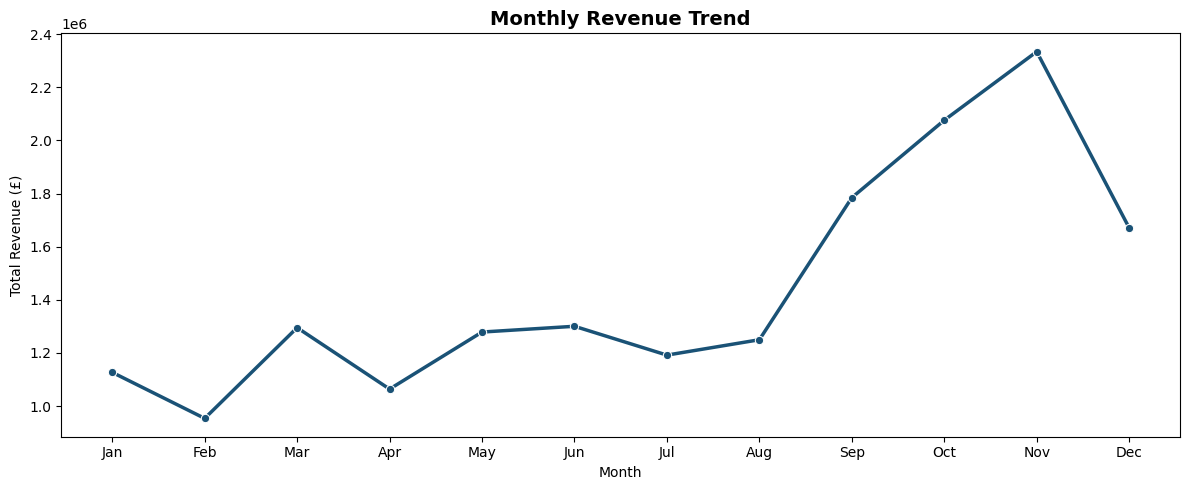

In [ ]:
# EXPLORATORY DATA ANALYSIS(EDA)

#monthly revenue trend
monthly = df_parquet.groupby(['Month', 'Month_Name'])['TotalPrice'].sum().reset_index()
monthly = monthly.sort_values('Month')

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x='Month_Name', y='TotalPrice',
             marker='o', color='#1a5276', linewidth=2.5)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('outputs/monthly_revenue.png', dpi=150)
plt.show()

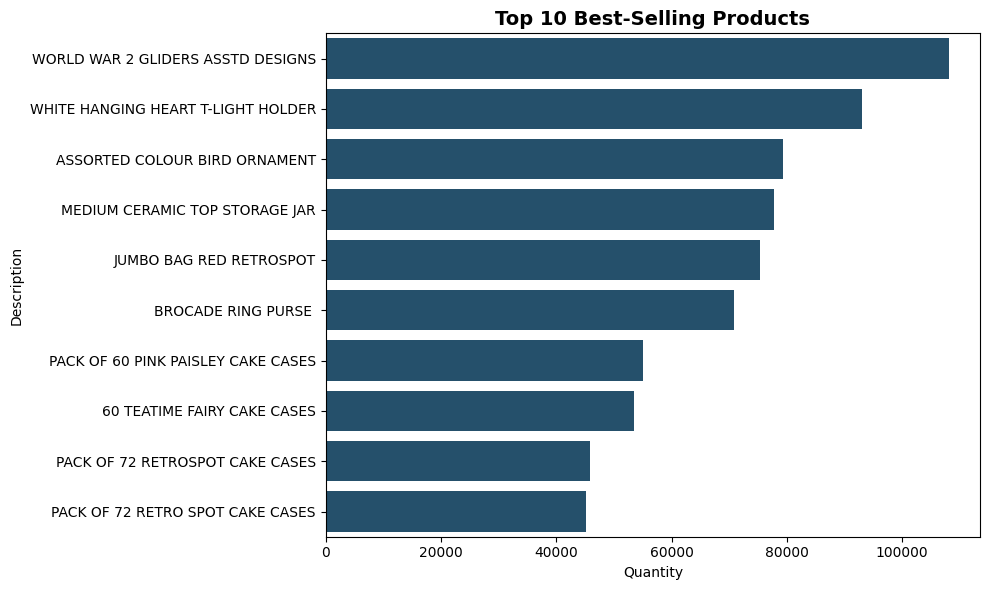

In [ ]:
#top 10 best selling products
top_products = df_parquet.groupby('Description')['Quantity'].sum()\
               .sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=top_products, y='Description', x='Quantity', color='#1a5276')
plt.title('Top 10 Best-Selling Products', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/top_products.png', dpi=150)
plt.show()


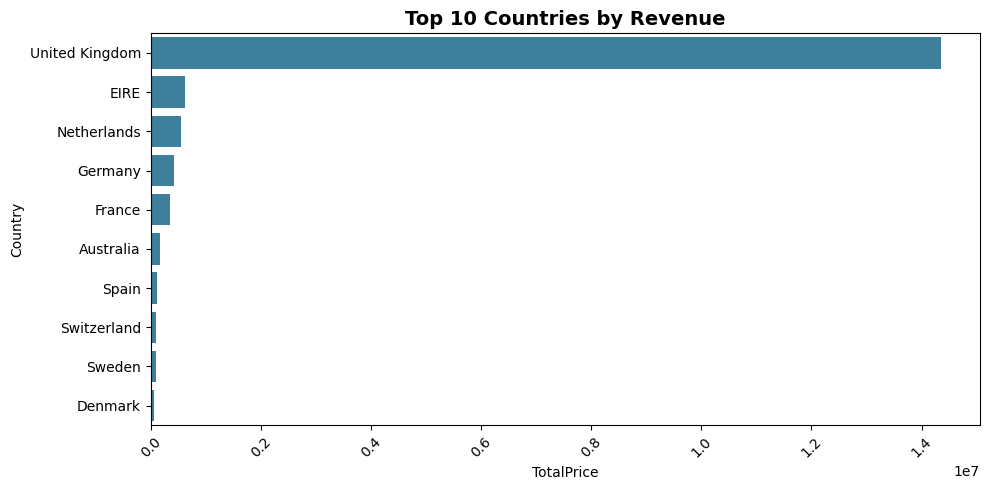

In [ ]:
# revenue by country(top 10)

country_rev = df_parquet.groupby('Country')['TotalPrice'].sum()\
                  .sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=country_rev, x='TotalPrice', y='Country', color='#2e86ab')
plt.title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/country_revenue.png', dpi=150)
plt.show()

## RFM Analysis

RFM (Recency, Frequency, Monetary) analysis is a marketing technique used to quantitatively rank and group customers based on their purchase behavior. It's often used for customer segmentation and personalized marketing strategies.

In [ ]:
# Recency: Days since last purchase
# Frequency: Total number of purchases
# Monetary: Total money spent

# Define a snapshot date for Recency calculation
snapshot_date = df_parquet['InvoiceDate'].max() + pd.DateOffset(days=1)

rfm = df_parquet.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

display(rfm.head())

,Customer ID,Recency,Frequency,Monetary
0,12346.0,321,12,77556.46
1,12347.0,35,7,5408.50
2,12348.0,71,5,2019.40
3,12349.0,14,4,4428.69
4,12350.0,305,1,334.40


In [ ]:
#score each metric 1-4 (4 = best)

rfm['R_Score'] = pd.qcut(rfm['Recency'],  q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=4, labels=[1, 2, 3, 4])

rfm['RFM_Score'] = (rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int))

#Label Segment
def segment(score):
  if score >=10: return 'Champions'
  elif score >= 7: return 'Loyal Customers'
  elif score >= 5: return 'pontential Loyalists'
  else:            return 'At Risk'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

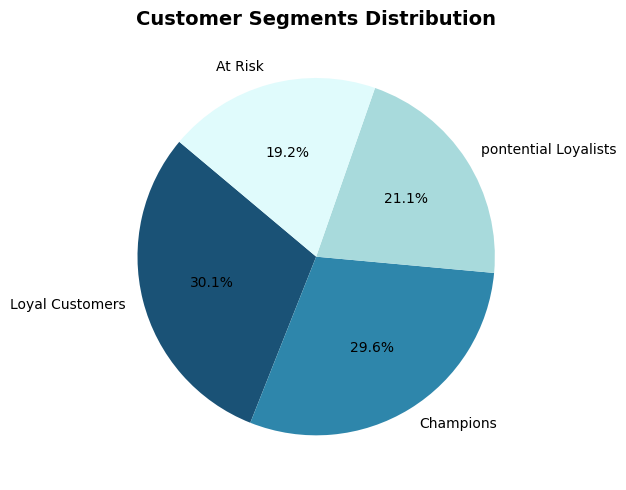

Champions = 29.6% of customers
Champions generate 80.5% of revenue


In [ ]:
#visualize the segments
seg_counts=rfm['Segment'].value_counts()

plt.figure(figsize=(8, 5))
colors = ['#1a5276', '#2e86ab', '#a8dadc', '#e0fbfc']
plt.pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Customer Segments Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/customer_segmets.png', dpi=150)
plt.show()

#Business insight: pareto check
champions = rfm[rfm['Segment'] == 'Champions']
total_rev = rfm['Monetary'].sum()
champ_rev = champions['Monetary'].sum()
print(f"Champions = {len(champions)/len(rfm)*100:.1f}% of customers")
print(f"Champions generate {champ_rev/total_rev*100:.1f}% of revenue")

